# Neural Network Classes Example

This notebook demonstrates both neural network classes in `rice_ml`:

- `SigmoidNeuralNetwork` (binary classification)
- `DenseNetwork` (regression)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rice_ml.Neural_Networks.dense_network_class import DenseNetwork
from rice_ml.Neural_Networks.neural_network_class import SigmoidNeuralNetwork
from rice_ml.processing.preprocessing import standardize, train_test_split
from rice_ml.processing.postprocessing import PostProcessor

from sklearn.datasets import make_regression

sns.set_theme()
np.random.seed(42)
# Load Spam Email dataset
#df = pd.read_csv("../../datasets/spam_email_dataset.csv")
df = pd.read_csv("/Users/ccarr21/Desktop/cmor438_carr/CMOR-438-SP-2026/examples/datasets/spam_email_dataset.csv")
df.head()


,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


## Binary Data Exploration: The Spam Email Dataset

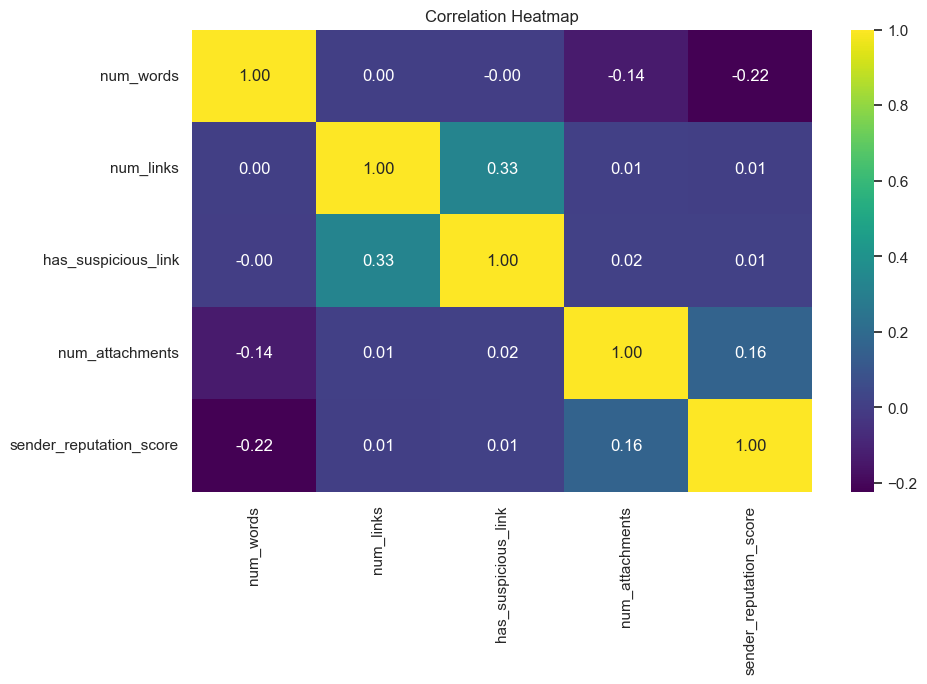

In [2]:
# Selecting features and target variable
features = ["num_words", "num_links", "has_suspicious_link","num_attachments", "sender_reputation_score"]
target = "label"
X = df[features].values
y = df[target].values
# Correlation heatmap of the features
corr_map = df[features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_map, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## SigmoidNeuralNetwork for Binary Classification

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42
)
# Standardize the features
X_train, X_test = standardize(X_train, X_test)
# Initialize and train the SigmoidNeuralNetwork
clf = SigmoidNeuralNetwork(hidden_layer_sizes=(12, 8), eta=0.1, epochs=250, random_state=42)
clf.train(X_train, y_train)
# Predict the test set
y_pred_cls = clf.predict(X_test)
# Classification Report
processor = PostProcessor()
print(processor.classification_metrics(y_test, y_pred_cls))
# Calculate the accuracy
acc = processor.accuracy(y_test, y_pred_cls)
print(f"Classification accuracy: {acc:.4f}")
# Calculate the ROC AUC score
roc_auc = processor.roc_auc_score(y_test, y_pred_cls)
print(f"ROC AUC score: {roc_auc:.4f}")
# Calculate the ROC curve
fpr, tpr, thresholds = processor.roc_curve(y_test, y_pred_cls)

{'classification_error': 0.2556, 'precision': 0.8608349900596421, 'recall': 0.43213572854291415, 'f1_score': 0.5754152823920266, 'confusion_matrix': array([[1428,   70],
       [ 569,  433]])}
Classification accuracy: 0.7444


AttributeError: 'PostProcessor' object has no attribute 'roc_auc_score'

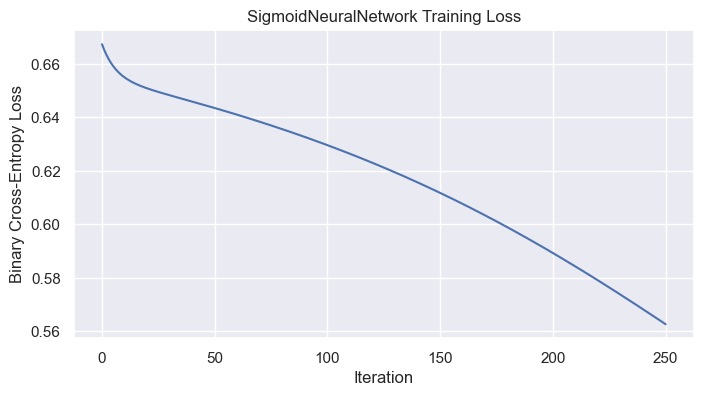

AttributeError: 'PostProcessor' object has no attribute 'plot_roc_curve'

In [4]:
# Plot classification training loss
plt.figure(figsize=(8, 4))
plt.plot(clf.loss_history_)
plt.title("SigmoidNeuralNetwork Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()
# Plot ROC curve
processor.plot_roc_curve(y_test, y_pred_cls)

## DenseNetwork for Regression Data

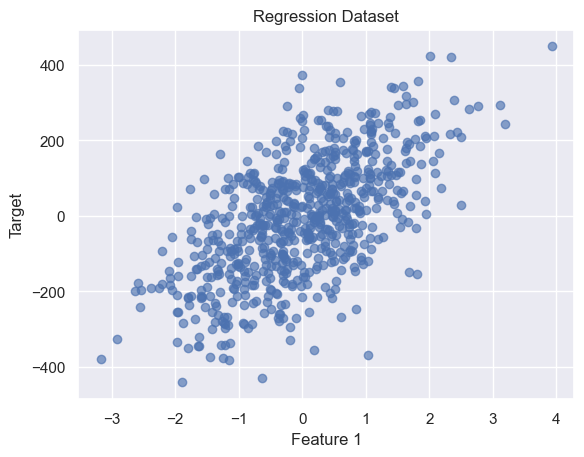

In [9]:
# Build a regression dataset
X_reg, y_reg = make_regression(
    n_samples=700,
    n_features=10,
    n_informative=8,
    noise=15.0,
    random_state=42,
)
# Plot the dataset
plt.scatter(X_reg[:, 0], y_reg, alpha=0.65)
plt.xlabel("Feature 1")
plt.ylabel("Target")
plt.title("Regression Dataset")
plt.show()

In [10]:
# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)
# Standardize the features
X_train_reg, X_test_reg = standardize(X_train_reg, X_test_reg)
# Initialize and train the DenseNetwork
reg = DenseNetwork(hidden_layer_sizes=(16, 8), eta=0.01, epochs=250, random_state=42)
reg.train(X_train_reg, y_train_reg)
# Predict the test set
y_pred_reg = reg.predict(X_test_reg)

processor = PostProcessor()
# Regression Report
print(processor.regression_metrics(y_test_reg, y_pred_reg))
# Calculate the ROC AUC score
roc_auc = processor.roc_auc_score(y_test_reg, y_pred_reg)
print(f"ROC AUC score: {roc_auc:.4f}")
# Calculate the ROC curve
fpr, tpr, thresholds = processor.roc_curve(y_test_reg, y_pred_reg)

{'mae': 95.33650565746971, 'mse': 14014.452788322797, 'rmse': 118.38265408548162, 'r2': 0.49149723832654857, 'sst': 4823040.153971566, 'ssr': 2370510.9160150765, 'sse': 2452529.2379564894, 'df_regression': 1.0, 'df_error': 173.0, 'df_total': 174.0, 'ms_regression': 2370510.9160150765, 'ms_error': 14176.469583563523, 'f_statistic': 167.21447480573678}


AttributeError: 'PostProcessor' object has no attribute 'roc_auc_score'

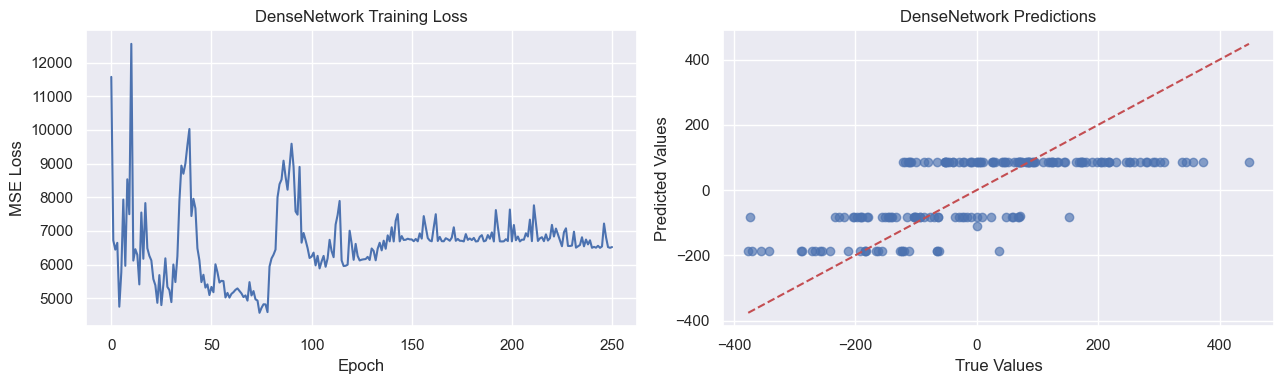

AttributeError: 'PostProcessor' object has no attribute 'plot_roc_curve'

In [11]:
# Plot regression training loss and prediction quality
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(reg.loss_history_)
axes[0].set_title("DenseNetwork Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")

axes[1].scatter(y_test_reg, y_pred_reg, alpha=0.65)
line_min = min(y_test_reg.min(), y_pred_reg.min())
line_max = max(y_test_reg.max(), y_pred_reg.max())
axes[1].plot([line_min, line_max], [line_min, line_max], "r--")
axes[1].set_title("DenseNetwork Predictions")
axes[1].set_xlabel("True Values")
axes[1].set_ylabel("Predicted Values")

plt.tight_layout()
plt.show()

# Plot ROC curve
processor.plot_roc_curve(y_test_reg, y_pred_reg)